# AULA 2: Modelagem SARIMA e Prophet:
## Insper - PADS
### Financial Analytics
#### Autor: Paloma Vaissman Uribe

In [112]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd
from prophet import Prophet
# !pip install prophet

# Install StatsForecast if you haven't already
# !pip install statsforecast

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

from sklearn.metrics import mean_squared_error

### 1. Simulando e analisando um processo ARIMA usando statsmodels

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3304500316.py:22: SyntaxWarning: invalid escape sequence '\s'
  axes[0, 0].set_title('Time Series Plot of $y \sim ARIMA(1,1,0)$')


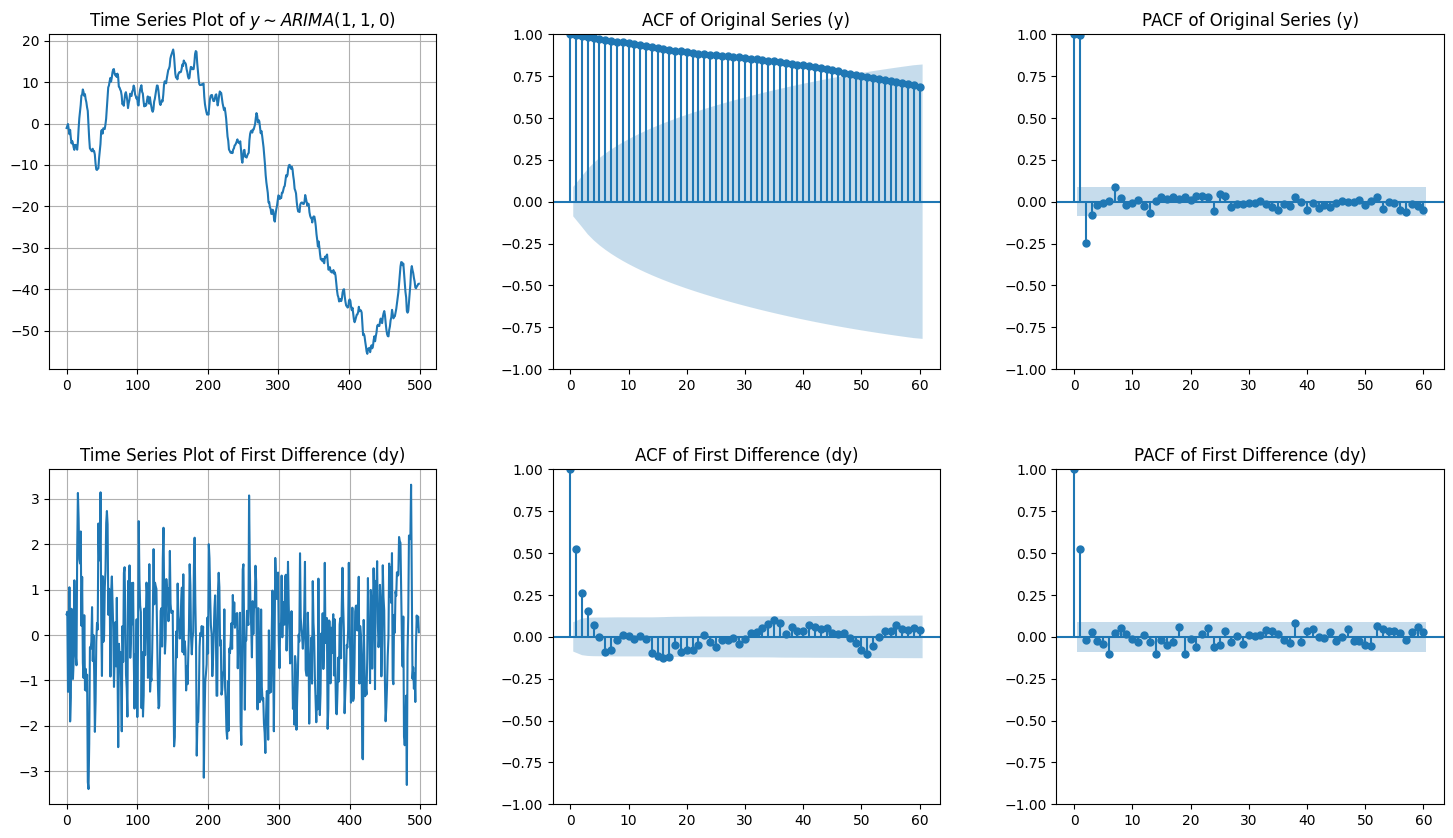

In [48]:
np.random.seed(123)

# Simulate an ARIMA(1,1,0) process with AR coefficient equal to 0.5
ar_params = [1, -0.5]  # AR coefficients for ArmaProcess are specified as [1, -ar1, -ar2, ...]
arma_process = ArmaProcess(ar=ar_params, ma=[1])
diff_y_stationary = arma_process.generate_sample(nsample=500)

# Integrate (I=1) the stationary series to get the ARIMA(1,1,0) process 'y'
y = np.cumsum(diff_y_stationary)

# Plotting using subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

axes[0, 0].plot(y)
axes[0, 0].set_title('Time Series Plot of $y \sim ARIMA(1,1,0)$')
axes[0, 0].grid(True)

# ACF Plot
plot_acf(y, lags=60, ax=axes[0, 1], title='ACF of Original Series (y)')

# PACF Plot
plot_pacf(y, lags=60, ax=axes[0, 2], title='PACF of Original Series (y)')

# Time Series Plot of Differenced Series
dy = np.diff(y)
axes[1, 0].plot(dy)
axes[1, 0].set_title('Time Series Plot of First Difference (dy)')
axes[1, 0].grid(True)

# ACF Plot of Differenced Series
plot_acf(dy, lags=60, ax=axes[1, 1], title='ACF of First Difference (dy)')

# PACF Plot of Differenced Series
plot_pacf(dy, lags=60, ax=axes[1, 2], title='PACF of First Difference (dy)')

plt.show()

### 2. Reproduzindo o exemplo das etapas de Box-Jenkins usando um processo IMA(1,1)

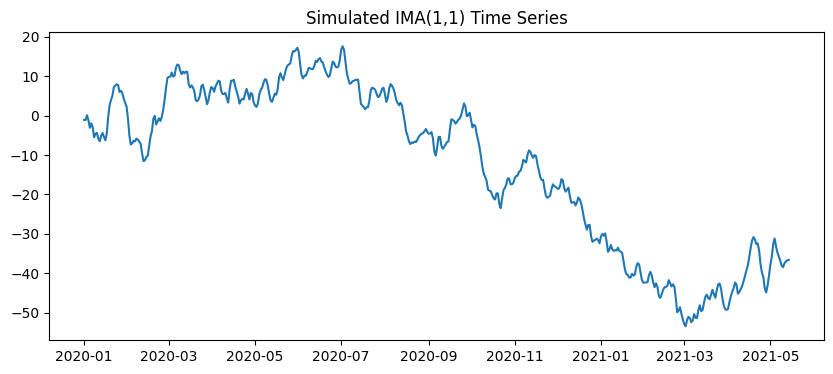

In [62]:
np.random.seed(123)

# Parameters for the stationary MA(1) process:
ar_params = [1]
ma_params = [1, 0.9] # MA(1) coefficient is 0.9

# Simulate the stationary difference series (the MA(1) part)
arma_process = ArmaProcess(ar=ar_params, ma=ma_params)
diff_ima1 = arma_process.generate_sample(nsample=500)

# Create the IMA(1,1) series with a time index
dates = pd.date_range(start='2020-01-01', periods=500, freq='D')
ima1 = pd.Series(np.cumsum(diff_ima1), index=dates)

# Plotting the series (optional, but often helpful):
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(ima1)
plt.title('Simulated IMA(1,1) Time Series')
plt.show()

In [65]:
## 1. Model estimation
model = ARIMA(endog=ima1, order=(0, 1, 1))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  500
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -710.907
Date:                Mon, 13 Oct 2025   AIC                           1425.813
Time:                        00:03:01   BIC                           1434.239
Sample:                    01-01-2020   HQIC                          1429.120
                         - 05-14-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.9090      0.019     48.887      0.000       0.873       0.945
sigma2         1.0080      0.066     15.372      0.000       0.879       1.136
Ljung-Box (L1) (Q):                   0.22   Jarque-

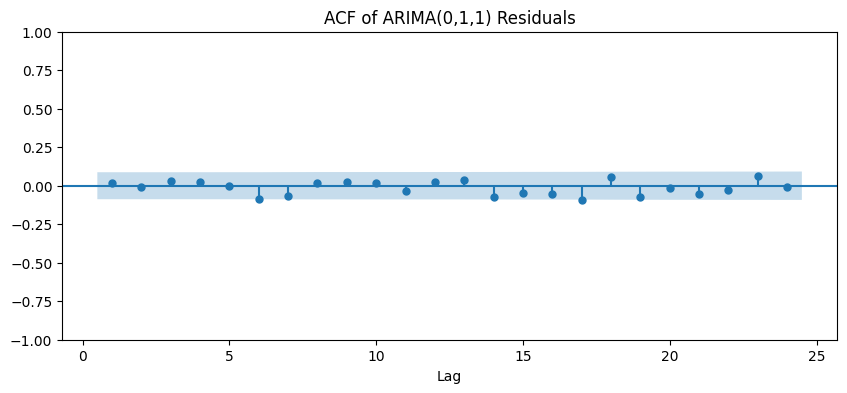


--- Ljung-Box Test (Q-Test) Results ---

Ljung-Box Test (Lags=24, Model DF=2 (MA1 + Constant)):
      lb_stat  lb_pvalue
24  27.504276   0.192697


In [66]:
## 2. Model diagnostic

res = results.resid

# Python: Plot the Autocorrelation Function (ACF) of the residuals
# We use lags=24 to align with the Ljung-Box test below.
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(res, lags=24, zero=False, ax=ax, title='ACF of ARIMA(0,1,1) Residuals')
ax.set_xlabel('Lag')
plt.show()

# 3. R: Box.test(res, lag=24, fitdf=4, type="Ljung")

print("\n--- Ljung-Box Test (Q-Test) Results ---")

# Calculate for Ljung-Box up to 24 lags, compensating for 2 estimated parameters (MA1 and Constant)
# The degrees of freedom for the Q-statistic is lags - model_df. (24 - 2 = 22)
lb_test_results_df = acorr_ljungbox(res, lags=[24], model_df=2, return_df=True)
print("\nLjung-Box Test (Lags=24, Model DF=2 (MA1 + Constant)):")
print(lb_test_results_df)

#

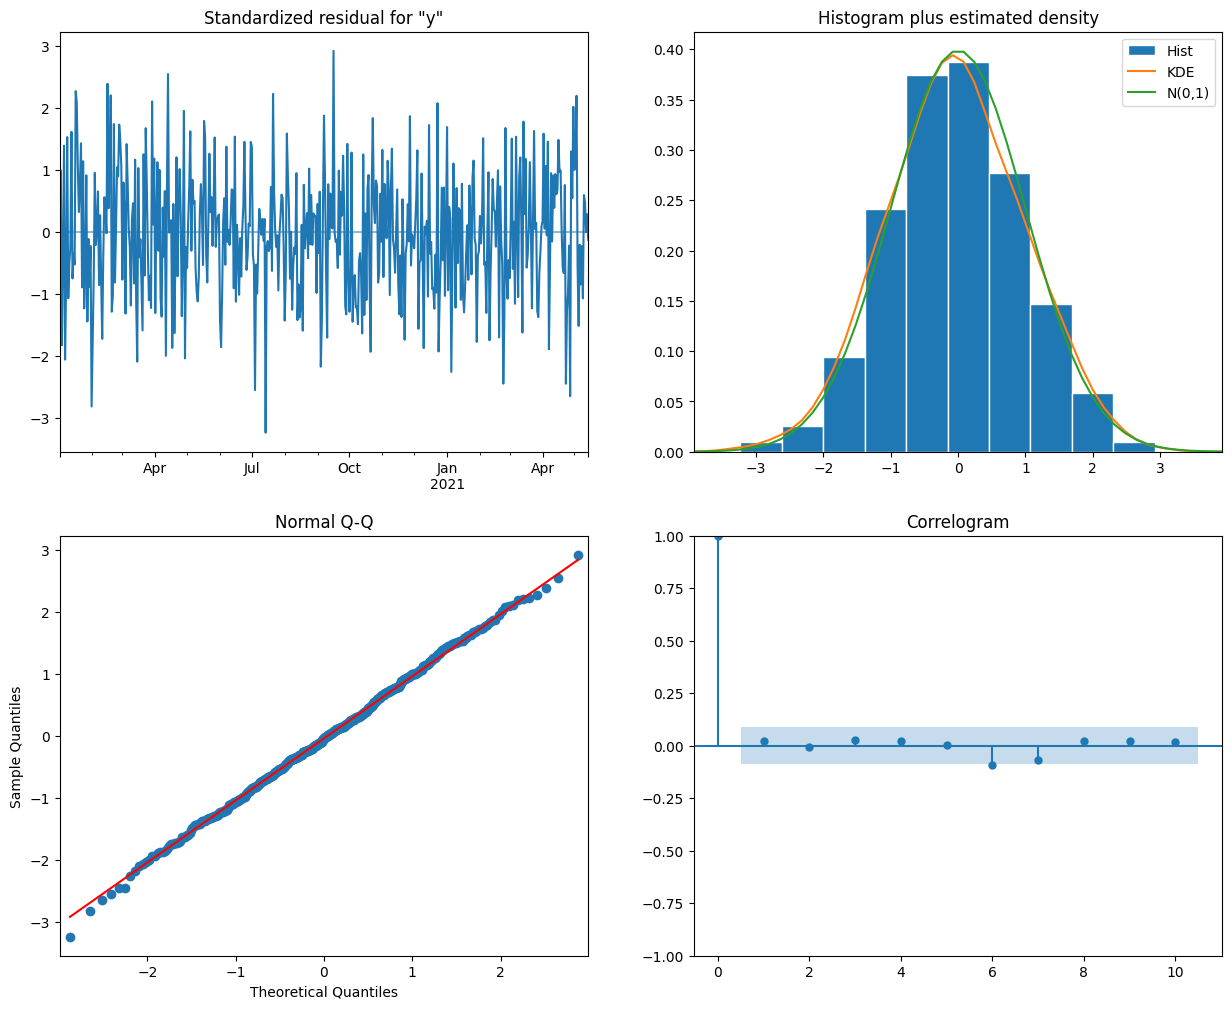

In [68]:
results.plot_diagnostics(figsize=(15, 12))
plt.show()

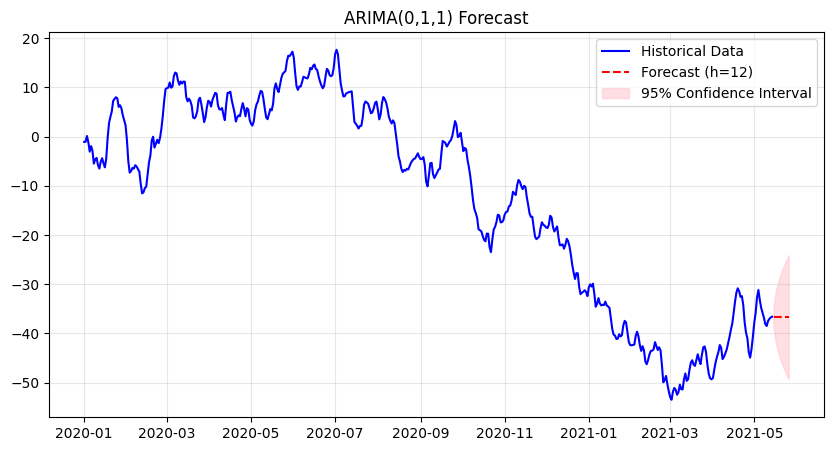

In [72]:
## 3. Model prediction

# Generate forecast for 12 steps ahead (h=12)
forecast_results = results.get_forecast(steps=12)

# Extract predictions and confidence intervals
mean_forecast = forecast_results.predicted_mean
conf_int = forecast_results.conf_int()

# Plot the forecast
plt.figure(figsize=(10, 5))
plt.plot(ima1, label='Historical Data', color='blue')
plt.plot(mean_forecast, label='Forecast (h=12)', color='red', linestyle='--')
plt.fill_between(mean_forecast.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='pink', alpha=0.5, label='95% Confidence Interval')
plt.title('ARIMA(0,1,1) Forecast')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
mean_forecast

array([-36.69689052, -36.69689052, -36.69689052, -36.69689052,
       -36.69689052, -36.69689052, -36.69689052, -36.69689052,
       -36.69689052, -36.69689052, -36.69689052, -36.69689052])

### 3. Auto ARIMA usando StatsForecast

In [63]:
# Create a DataFrame from the 'ima1' numpy array
data = pd.DataFrame({
    'unique_id': 'ima1_series',  # A unique identifier for our single series
    'ds': range(len(ima1)),      # Using integers as time steps
    'y': ima1                    # The time series values
})

# Initializate StatsForecast
sf = StatsForecast(
    models=[AutoARIMA()],
    freq=1 # Frequency of the data (1 for no specific frequency, or hourly, daily etc.)
)

# Fit the model to the data
sf.fit(data)

# Get the results
forecast_df = sf.predict(h=10) # Forecast 10 steps ahead
print("\nForecast:")
print(forecast_df)

# Model


Forecast:
     unique_id   ds  AutoARIMA
0  ima1_series  500 -36.696439
1  ima1_series  501 -36.696439
2  ima1_series  502 -36.696439
3  ima1_series  503 -36.696439
4  ima1_series  504 -36.696439
5  ima1_series  505 -36.696439
6  ima1_series  506 -36.696439
7  ima1_series  507 -36.696439
8  ima1_series  508 -36.696439
9  ima1_series  509 -36.696439


In [64]:
fitted_autoarima_model = sf.fitted_[0][0].model_
print(fitted_autoarima_model)

{'coef': {'ma1': np.float64(0.9092546172913577)}, 'sigma2': np.float64(1.0099914279544253), 'var_coef': array([[1.8825789e-05]]), 'mask': array([ True]), 'loglik': np.float64(-710.4546259869771), 'aic': np.float64(1424.9092519739543), 'arma': (0, 1, 0, 0, 1, 1, 0), 'residuals': array([-1.08562961e-03,  1.50039447e-02,  9.98504972e-01, -1.83051895e+00,
       -4.01135932e-01,  1.39637672e+00, -2.06379156e+00, -7.84313377e-01,
        1.53518707e+00, -1.07046473e+00, -4.96196564e-01, -2.58111314e-01,
        1.62215373e+00, -7.51336945e-01, -3.39027886e-01, -5.24880884e-01,
        2.27989884e+00,  2.10059195e+00,  1.06583294e+00,  3.22762000e-01,
        7.90606906e-01,  1.43458651e+00, -8.95269461e-01,  1.14525656e+00,
       -1.23469414e+00, -6.44129510e-01,  9.17798309e-01, -1.44554158e+00,
       -1.12140977e-01, -8.85585871e-01, -2.26191570e-01, -2.82236728e+00,
       -1.72428477e+00, -7.26633645e-01,  9.58031453e-01, -2.09873476e-01,
        3.73775707e-02,  6.56751525e-01, -8.57

In [115]:
arima_string(fitted_autoarima_model)

'ARIMA(0,1,1)                   '

### 4. Modelagem sazonal: Prophet
Para os tópicos a seguir (inclusive ARIMA), vamos usar novamente a clássica série Airline e comparar dois modelos: Prophet e SARIMA, de acordo com métricas preditivas

In [75]:
# Reading airline data
url="https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
airline=pd.read_csv(url,parse_dates = ['Month'],index_col = ['Month'])
airline.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [82]:
# Transform dataset to Prophet
df = pd.DataFrame(airline.reset_index())
df.columns = ['ds', 'y']
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [85]:
# get index for training dataset
idx = df.shape[0]-12
df_train = df.iloc[:idx]
df_test = df.iloc[idx:]
df_train

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
127,1959-08-01,559
128,1959-09-01,463
129,1959-10-01,407
130,1959-11-01,362


In [86]:
## Prophet using default values

m = Prophet()
m.fit(df_train)

# make future dataframe
future = m.make_future_dataframe(periods=12, freq='MS')

# predict method
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmprt_wfu7n/izw30l_o.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprt_wfu7n/flarua18.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50781', 'data', 'file=/tmp/tmprt_wfu7n/izw30l_o.json', 'init=/tmp/tmprt_wfu7n/flarua18.json', 'output', 'file=/tmp/tmprt_wfu7n/prophet_modeld3axpt37/prophet_model-20251013014414.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:44:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:44:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
139,1960-08-01,527.280590,500.638342,551.991252
140,1960-09-01,486.059339,459.498518,511.913797
141,1960-10-01,452.372785,425.321933,478.266611
142,1960-11-01,422.546610,394.918101,447.231719
143,1960-12-01,447.861729,422.664873,473.433933


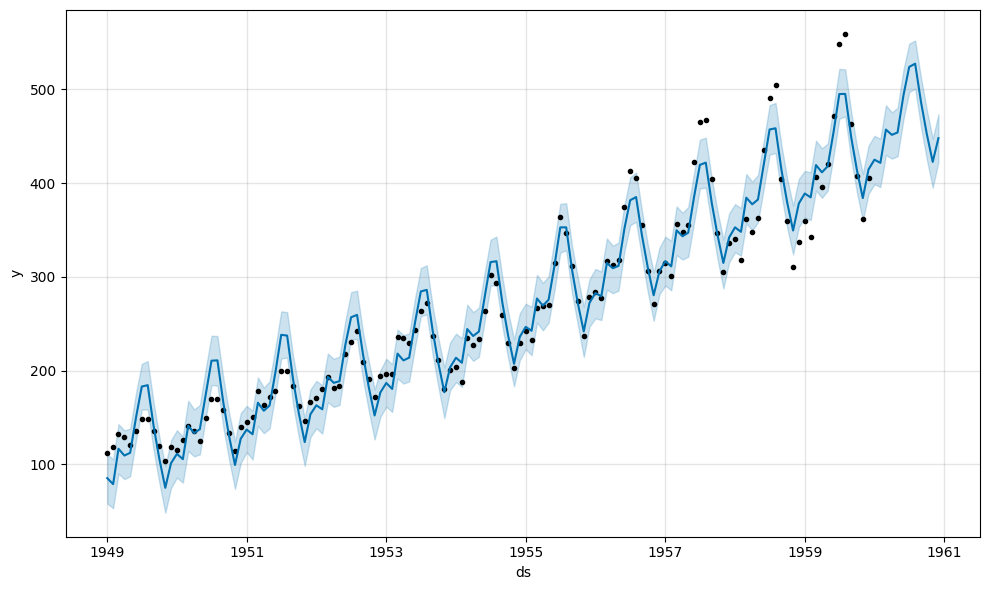

In [87]:
fig1 = m.plot(forecast)

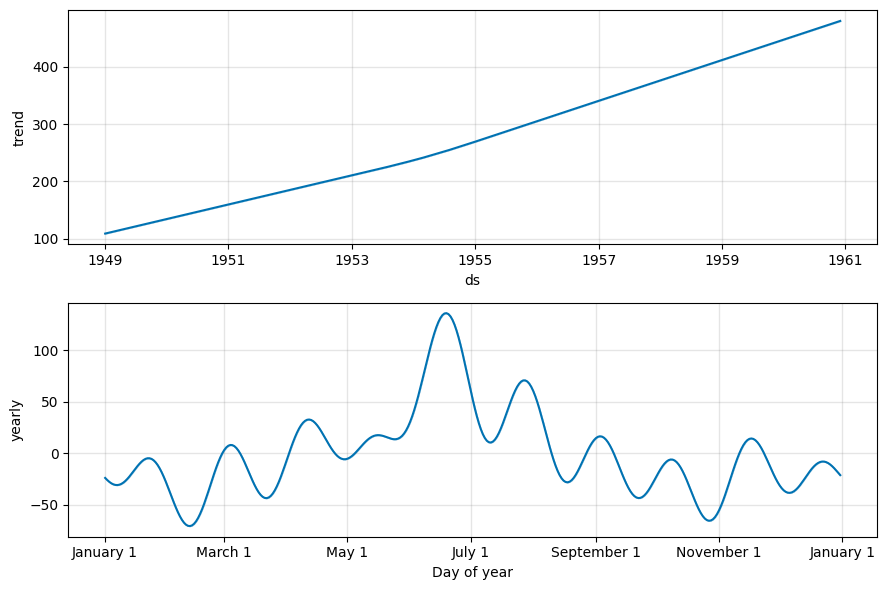

In [88]:
# components
fig2 = m.plot_components(forecast)

In [92]:
# RMSE Prophet w/ default values

y_true = df_test['y']
y_pred = forecast.iloc[idx:]['yhat']
np.sqrt(mean_squared_error(y_true, y_pred))

np.float64(43.06779943855511)

In [93]:
## improving fit with multiplicative seasonality

# fit method
m2 = Prophet(seasonality_mode='multiplicative')
m2.fit(df_train)

# make future dataframe: note to specify frequency here
future = m2.make_future_dataframe(periods=12, freq='MS')

# predict method
forecast2 = m2.predict(future)
forecast2[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmprt_wfu7n/o7b0rq10.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprt_wfu7n/e_xqfw5e.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=78082', 'data', 'file=/tmp/tmprt_wfu7n/o7b0rq10.json', 'init=/tmp/tmprt_wfu7n/e_xqfw5e.json', 'output', 'file=/tmp/tmprt_wfu7n/prophet_modely3z3irvs/prophet_model-20251013014634.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:46:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:46:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
139,1960-08-01,573.161035,560.506141,584.914388
140,1960-09-01,496.542106,483.518880,508.761994
141,1960-10-01,433.293194,421.550570,446.541725
142,1960-11-01,379.728025,366.920953,392.332337
143,1960-12-01,420.369765,407.916878,433.798482


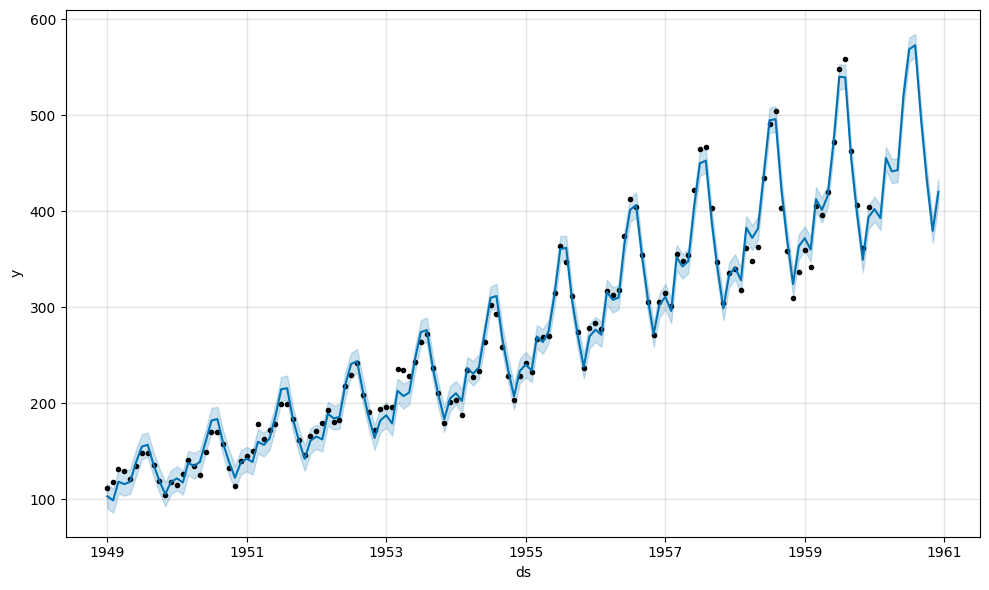

In [95]:
fig3 = m2.plot(forecast2)

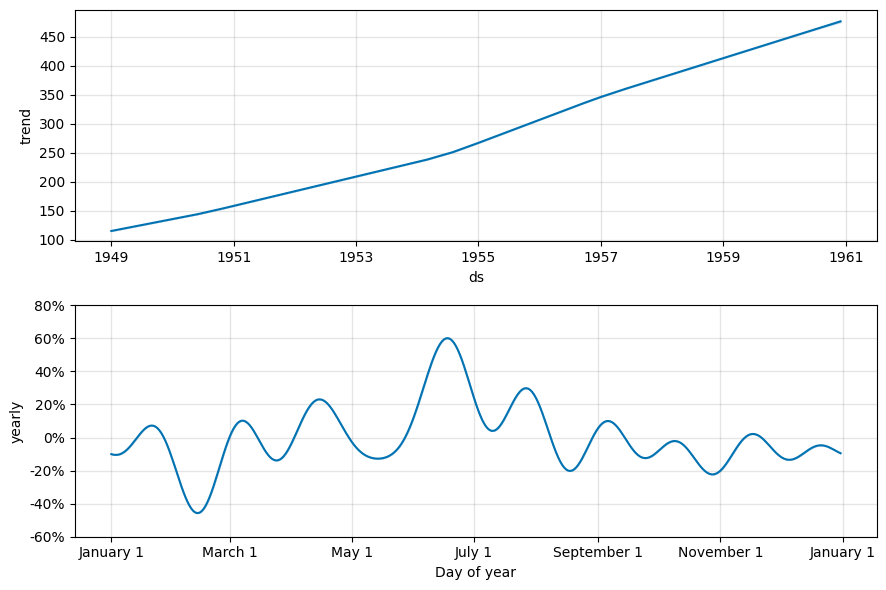

In [96]:
# components
fig4 = m2.plot_components(forecast2)

In [98]:
# RMSE: better than additive seasonality

from sklearn.metrics import mean_squared_error
import numpy as np
y_true = df_test['y']
y_pred = forecast2.iloc[idx:]['yhat']
np.sqrt(mean_squared_error(y_true, y_pred))

np.float64(25.84359362409569)

### 5. Modelagem SARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  132
Model:                 ARIMA(2, 1, 0)   Log Likelihood                -628.265
Date:                Mon, 13 Oct 2025   AIC                           1262.530
Time:                        01:58:06   BIC                           1271.156
Sample:                    01-01-1949   HQIC                          1266.035
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3589      0.096      3.754      0.000       0.172       0.546
ar.L2         -0.2182      0.074     -2.952      0.003      -0.363      -0.073
sigma2       856.2091    101.066      8.472      0.0

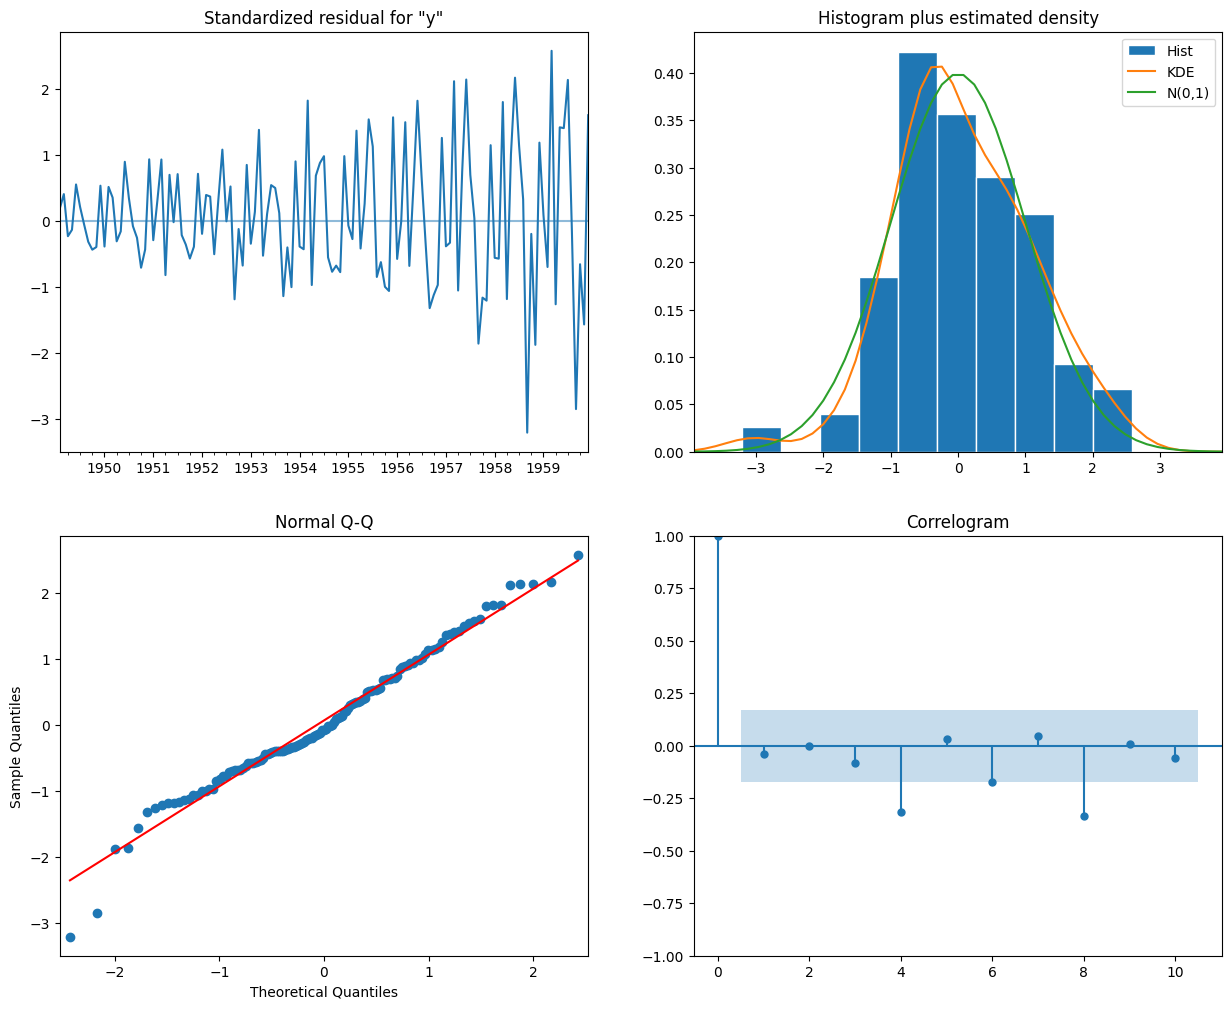

In [113]:
## ARIMA é suficiente?

# fit model
model = ARIMA(endog=df_train.set_index('ds'), order=(2,1,0), freq='MS')
model_fit = model.fit()

# summary of fit model
print(model_fit.summary())

# line plot of residuals
model_fit.plot_diagnostics(figsize=(15, 12))
plt.show()

In [116]:
## SARIMA é mais adequado: vamos usar o Auto Arima para detectar as ordens

models = [AutoARIMA(season_length=12)]
sf = StatsForecast(models=models, freq='MS')
df = df_train.copy()
df["unique_id"]="1"
df.columns=["ds", "y", "unique_id"]
sf.fit(df)

StatsForecast(models=[AutoARIMA])

In [117]:
arima_string(sf.fitted_[0,0].model_)

'ARIMA(1,1,0)(0,1,0)[12]                   '

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                  132
Model:             ARIMA(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -447.951
Date:                          Mon, 13 Oct 2025   AIC                            899.902
Time:                                  02:04:21   BIC                            905.460
Sample:                              01-01-1949   HQIC                           902.159
                                   - 12-01-1959                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2431      0.090     -2.697      0.007      -0.420      -0.066
sigma2       108.8757     13.306      8.183      0.

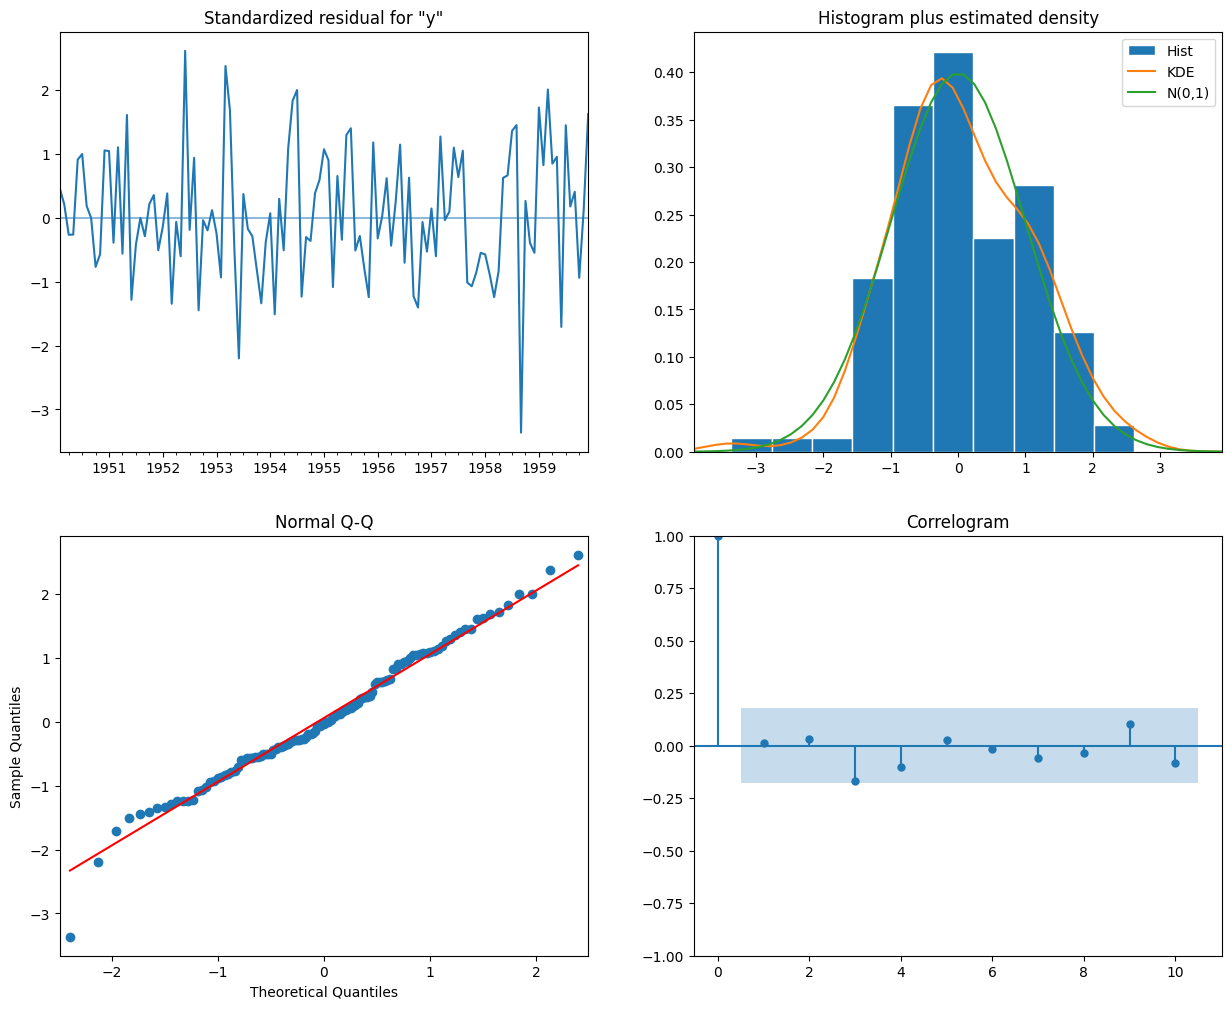

In [125]:
## summary of auto model

# fit model
model = ARIMA(endog=df_train.set_index('ds'), order=(1,1,0), seasonal_order=(0,1,0,12), freq='MS')
model_fit = model.fit()

# summary of fit model
print(model_fit.summary())

# line plot of residuals
model_fit.plot_diagnostics(figsize=(15, 12))
plt.show()

In [129]:
forecast_results_sarima = model_fit.get_forecast(steps=12)
forecast_results_sarima.predicted_mean

,predicted_mean
1960-01-01,424.109830
1960-02-01,407.055669
1960-03-01,470.825702
1960-04-01,460.881615
1960-05-01,484.868020
1960-06-01,536.871326
1960-07-01,612.870522
1960-08-01,623.870717
1960-09-01,527.870670
1960-10-01,471.870681


In [134]:
# RMSE SARIMA: best model

y_true = df_test['y']
y_pred = forecast_results_sarima.predicted_mean.values
np.sqrt(mean_squared_error(y_true, y_pred))

np.float64(23.93167319781741)